In [1]:
import duckdb
import pandas as pd
import logging

In [2]:
logging.basicConfig(
    level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s',
    filename='pipeline.log'
)
logger = logging.getLogger(__name__)

## Data Preparation

In [ ]:
con = duckdb.connect('nyc_ems.duckdb')
con.execute("""
    --- create table of demographics from csv 
    CREATE TABLE IF NOT EXISTS demographics AS
    SELECT * FROM read_csv_auto('data/Demographics.csv');
    ALTER TABLE demographics ADD PRIMARY KEY (region_name);
""")
logger.info("Created demographics table")

con.execute("""
    --- create table of events, keeping only one record for event id 
    CREATE TABLE IF NOT EXISTS events AS
    SELECT * FROM ( 
        SELECT *,
           ROW_NUMBER() OVER (PARTITION BY id ORDER BY start_date_time ASC) AS rn
        FROM read_csv_auto('data/NYC_Events2.csv')) sub
    WHERE rn = 1;
    ALTER TABLE events ADD PRIMARY KEY (id);
""")
logger.info("Created events table")

con.execute("""
    --- create table of weather data
    CREATE TABLE IF NOT EXISTS weather AS
    SELECT * FROM read_csv_auto('data/Weather.csv');
    ALTER TABLE weather ADD PRIMARY KEY (locationtimeID);
""")
logger.info("Created weather table")

con.execute("""
    --- create table of incidents from incident csv, keeping only one incident id
    CREATE TABLE IF NOT EXISTS incidents AS
    SELECT * FROM ( 
        SELECT *,
            ROW_NUMBER() OVER (PARTITION BY cad_incident_id ORDER BY incident_datetime ASC) AS rn
        FROM read_csv_auto('data/EMS_Incidents.csv')) sub
    WHERE rn = 1;
    ALTER TABLE incidents ADD PRIMARY KEY (cad_incident_id);        
""")
logger.info("Created incidents table")

con.execute("""
    --- create junction table linking events and incidents by locationtimeID 
    CREATE TABLE IF NOT EXISTS eventjunction AS
    SELECT e.id, e.locationtimeID, i.cad_incident_id
    FROM events e
    JOIN incidents i ON e.locationtimeID = i.locationtimeID;
    ALTER TABLE eventjunction ADD PRIMARY KEY (id, locationtimeID);
""")
logger.info("Created event junction table")
con.close()

## Query

In [ ]:
con = duckdb.connect('nyc_ems.duckdb') 

df = con.execute("""
    --- query to create table of daily incident counts by borough, 
        --- joined with weather, events, and demographics data
    SELECT 
        c.incident_datetime::DATE as date,
        c.borough,
        COUNT(c.cad_incident_id) as total_calls,
        AVG(w.temperature) as avg_temp,
        AVG(w.weathercode) as weathercode,
        COUNT(DISTINCT e.id) as num_events,
        AVG(crime_viol_rt) as violent_crime_rate,
        AVG(hh_inc_med_adj) as household_income,
        AVG(hh_u18_pct) as pct_under_18,
        AVG(pop_65p_pct) as pct_over_65,
        AVG(pop_num) as population
    FROM incidents c
    LEFT JOIN weather w ON c.locationtimeID = w.locationtimeID
    LEFT JOIN eventjunction ej
        ON c.cad_incident_id = ej.cad_incident_id
    LEFT JOIN events e
        ON ej.id = e.id
    LEFT JOIN demographics d ON c.borough = d.region_name
    GROUP BY c.incident_datetime::DATE, c.borough;
""").fetchdf()

con.close()

## Solution Analysis

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [ ]:
#drop target variable from X and save in y 
X = df.drop(columns=["total_calls", "date"])
y = df["total_calls"]

#one hot encoding for categorical variable, borough 
X = pd.get_dummies(X, columns=["borough"], drop_first=True)

#train test split for evaluation and training  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#create and train regressor 
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

#predict on testing data 
y_pred = model.predict(X_test)

#assessment metrics 
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
r2 = model.score(X_test, y_test)
print(f"R^2: {r2}")

Mean Squared Error: 3844.237883412857
R^2: 0.9673268045715807


In [ ]:
#create param grid for hyperparameter tuning with gridsearch 
param_grid = {
    'max_depth': [None, 10, 20],
    'max_features': [2, 3, 4]
}

#gridsearch to find optimal hyperparameters 
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5, 
    scoring='neg_mean_squared_error'
)

grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)

#evaluate best parameters on test set 
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = best_model.score(X_test, y_test)
print(f"Mean Squared Error: {mse}")
print(f"R^2: {r2}")

## Analysis Rationale      
When reading in the data from the tables, as I was using DuckDB I just read in the CSVs, as it infers the column name and types. I then created a primary key for each table which would later help with querying and eliminating duplicates. For the events table, I was repeatedly encountering issues with repeat rows with the same id, so I decided to select only one of them by choosing one with the earliest start. In order to combine the events and incidents table, I created a junction table which took in the eventID and incidentID from the events and incidents table, and then joined them on the locationtimeID. Since these would have a many to many relationship, at one given call time there can be many events occurring, and at the time of one event there can be many calls happening, a junction table would help with this. Since they would need to overlap on both time and location, I created a locationtimeID to just have one row overlapping. For the final query, I joined the weather on the locationtimeID, but did not need a junction table since this was not a many to many relationship. I created a dataframe that aggregated the total number of incidents for each day and borough. I then used this dataframe to train the predictive model.     
For this problem, I decided to solve it with a random forest. As I knew I wanted it to be predictive, I would have to do some algorithm that could return a prediction output based on data it was trained on. The output variable, the number of ems calls, was also numeric, so I knew I would need a model with a numeric output, not a category or binary output. I also considered creating a linear regression, however I did not think that the number of calls would have a direct linear relationship with the variables and there would instead be more complex relationships and interactions. I figured that a random forest could help with these nonlinear experiences and with the combination of categorical and numeric features that would be significant. The initial R^2 value was quite high, showing that the model had good predictions, however I decided to also do some hyperparameter training to further optimize the model. I used GridSearch for CrossValidation to tune the hyperparameters of max depth and max features and then found the optimal parameters and ran a model using these, which had increased predictive accuracy and lower error.  

## Visualization 

In [13]:
import geopandas as gpd
from geodatasets import get_path
import matplotlib.pyplot as plt


/home/nylup/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


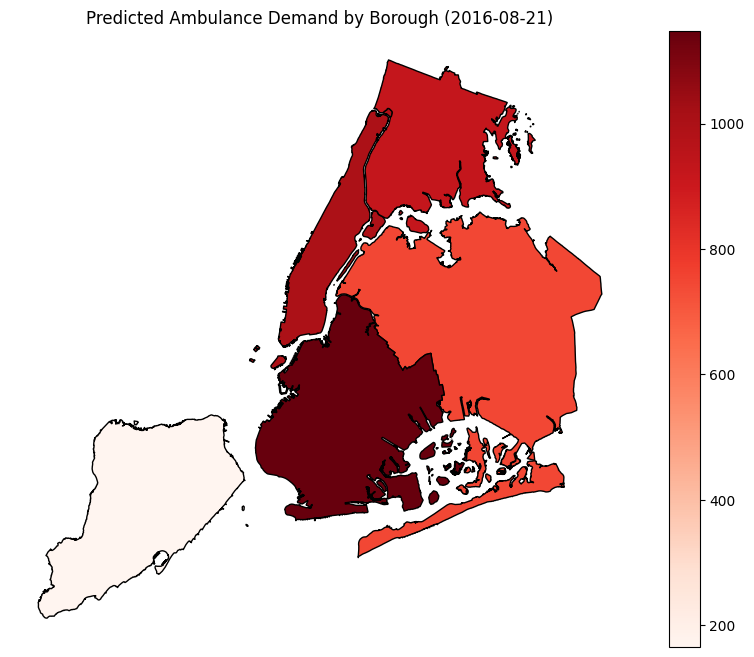

In [ ]:
target_date = "2016-08-21"

boroughs = ["MANHATTAN", "BROOKLYN", "QUEENS", "BRONX", "STATEN ISLAND"]

#filter for given date 
dated_df = df[df["date"] == target_date].copy()

#prepare X
sample_X = dated_df.drop(columns=["total_calls", "date"])
sample_X = pd.get_dummies(sample_X, columns=["borough"], drop_first=True)

#fix borough names 
dated_df["borough"] = (dated_df["borough"].str.replace("RICHMOND / STATEN ISLAND", "STATEN ISLAND"))

#align columns 
for col in X.columns:
    if col not in sample_X.columns:
        sample_X[col] = 0
sample_X = sample_X[X.columns]

#predict 
dated_df["predicted_calls"] = model.predict(sample_X)

#load map of nyc boroughs and shapes
nyc = gpd.read_file(get_path('nybb')) 

#standardize borough names 
nyc["borough"] = nyc["BoroName"].str.upper()

#information for each borough on given date 
merged = nyc.merge(dated_df, on="borough")

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

merged.plot(
    column="predicted_calls",
    cmap="Reds",
    legend=True,
    edgecolor="black",
    ax=ax,
    legend_kwds={"label": "Predicted Number of Ambulance Calls"}
)

plt.title(f"Predicted Ambulance Demand by Borough ({target_date})")
plt.axis("off")
plt.show()

## Visualization Rationale 

For the visualization for this project, initially I was unsure how I wanted to demonstrate the success of this data pipeline. Since the goal of this project was predicting the number of ambulance calls, I wanted to create some visual that could show this. The data is about locations in New York City, which lends this to a map being used. For the visual I decided to pick a random date and then use the model to predict the amount of EMS calls that will be called for each borough of New York. This visual will then show the model's predicted ambulance demand for each borough, showing how the model draws on borough specific information and the training data in order to predict the relationship between the date and borough with the amount of EMS calls. In order to have a map of New York City and shapes of the boroughs, I needed to import geopandas and geodatasets. Initially I noticed there were issues with the dataset not having Staten Island, until I realized the dataset had it saved as Richmond/Staten Island while the geofiles did not, so I decided to replace the dataset with just Staten Island so the mapping would work. Because the project pertains to health, I decided to make the color palette be red, as that is a color often affiliated with hospitals, and that is a readable color for viewers. 